In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

USERS_PATH = "spotify_users.csv"
LISTENING_PATH = "spotify_listening_daily.csv"
PLANS_PATH = "spotify_plans.csv"

users = pd.read_csv(USERS_PATH, parse_dates=["signup_date"])
listening = pd.read_csv(LISTENING_PATH, parse_dates=["date"])
plans = pd.read_csv(PLANS_PATH)

users.head(), listening.head(), plans


(   user_id country                plan signup_date
 0  U100000      SE                Free  2025-04-25
 1  U100001      IT  Premium_Individual  2025-08-11
 2  U100002      PL             Student  2024-11-14
 3  U100003      UK         Premium_Duo  2024-07-10
 4  U100004      FR                Free  2025-07-03,
    user_id       date  minutes  sessions  skips  likes
 0  U100000 2025-12-01    33.34         2      9      2
 1  U100000 2025-12-02    16.26         0     14      0
 2  U100000 2025-12-03    53.24         1     13      0
 3  U100000 2025-12-04    19.34         6      9      1
 4  U100000 2025-12-05    90.87         1      8      1,
                  plan  monthly_price_eur
 0                Free               0.00
 1  Premium_Individual              10.99
 2         Premium_Duo              14.99
 3      Premium_Family              17.99
 4             Student               5.99)

## 1) Data diagnosis (quality checks)

In [2]:
def quality_report(df, key_cols=None):
    out = {"rows": len(df), "cols": df.shape[1], "missing_cells": int(df.isna().sum().sum())}
    if key_cols:
        out["duplicate_keys"] = int(df.duplicated(key_cols).sum())
    return out

print("Users:", quality_report(users, ["user_id"]))
print("Listening:", quality_report(listening, ["user_id","date"]))
print("Plans:", quality_report(plans, ["plan"]))

print("\nMissing by col (users):")
display(users.isna().sum().sort_values(ascending=False))

print("\nMissing by col (listening):")
display(listening.isna().sum().sort_values(ascending=False))

display(listening[["minutes","sessions","skips","likes"]].describe())


Users: {'rows': 2500, 'cols': 4, 'missing_cells': 0, 'duplicate_keys': 0}
Listening: {'rows': 225000, 'cols': 6, 'missing_cells': 0, 'duplicate_keys': 0}
Plans: {'rows': 5, 'cols': 2, 'missing_cells': 0, 'duplicate_keys': 0}

Missing by col (users):


,0
user_id,0
country,0
plan,0
signup_date,0



Missing by col (listening):


,0
user_id,0
date,0
minutes,0
sessions,0
skips,0
likes,0


,minutes,sessions,skips,likes
count,225000.000000,225000.000000,225000.000000,225000.000000
mean,35.934019,2.084542,7.434293,1.039018
std,30.384142,1.690055,4.408496,1.108159
min,0.000000,0.000000,0.000000,0.000000
25%,14.640000,1.000000,5.000000,0.000000
50%,28.950000,2.000000,7.000000,1.000000
75%,49.560000,3.000000,10.000000,2.000000
max,384.360000,14.000000,49.000000,9.000000


## 2) Feature engineering + churn definition (KPI)
**Churn (14-day):** 0 sessions in last 14 days.

In [3]:
last_date = listening["date"].max()
cutoff = last_date - pd.Timedelta(days=14)

last14_sessions = listening[listening["date"] > cutoff].groupby("user_id")["sessions"].sum()
churn_flag = (last14_sessions == 0).rename("churned_14d").reset_index()

agg = listening.groupby("user_id").agg(
    total_minutes=("minutes","sum"),
    total_sessions=("sessions","sum"),
    active_days=("sessions", lambda x: (x>0).sum()),
    total_skips=("skips","sum"),
    total_likes=("likes","sum"),
    avg_minutes_active_day=("minutes", lambda x: x[x>0].mean() if (x>0).any() else 0),
).reset_index()

df = (users.merge(agg, on="user_id", how="left")
          .merge(churn_flag, on="user_id", how="left")
          .merge(plans, on="plan", how="left"))

churn_rate = float(df["churned_14d"].mean())
retention_rate = 1 - churn_rate

print(f"Window ends: {last_date.date()}")
print(f"14-day churn rate: {churn_rate:.1%}")
print(f"14-day retention rate: {retention_rate:.1%}")

df["clv_proxy"] = df["monthly_price_eur"] * (1 / churn_rate)  # rough
df.head()


Window ends: 2026-02-28
14-day churn rate: 16.9%
14-day retention rate: 83.1%


,user_id,country,plan,signup_date,total_minutes,total_sessions,active_days,total_skips,total_likes,avg_minutes_active_day,churned_14d,monthly_price_eur,clv_proxy
0,U100000,SE,Free,2025-04-25,2526.62,158,70,817,64,28.073556,False,0.00,0.000000
1,U100001,IT,Premium_Individual,2025-08-11,2893.80,220,82,710,87,32.153333,False,10.99,64.952719
2,U100002,PL,Student,2024-11-14,3286.40,158,65,499,72,46.287324,True,5.99,35.401891
3,U100003,UK,Premium_Duo,2024-07-10,2700.84,160,42,224,68,64.305714,True,14.99,88.593381
4,U100004,FR,Free,2025-07-03,3121.40,180,76,726,101,34.682222,False,0.00,0.000000


## 3) K-Means clustering (behavioral segmentation)

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

seg_features = ["total_minutes","total_sessions","active_days","total_skips","total_likes"]
X = df[seg_features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
df["segment_kmeans"] = kmeans.fit_predict(X_scaled)

kmeans_profile = df.groupby("segment_kmeans").agg(
    users=("user_id","count"),
    churn_rate=("churned_14d","mean"),
    premium_share=("plan", lambda x: (x!="Free").mean()),
    avg_minutes=("total_minutes","mean"),
    avg_active_days=("active_days","mean"),
).sort_values("users", ascending=False)

display(kmeans_profile.style.format({
    "churn_rate":"{:.1%}",
    "premium_share":"{:.1%}",
    "avg_minutes":"{:.0f}",
    "avg_active_days":"{:.1f}",
}))


,users,churn_rate,premium_share,avg_minutes,avg_active_days
segment_kmeans,,,,,
0,1100,4.1%,53.5%,3398,78.9
3,540,9.1%,23.3%,2236,66.7
2,534,0.6%,93.1%,4922,85.9
1,326,100.0%,42.9%,1572,38.4


## 4) RFM analysis (Recency–Frequency–Monetary)

In [8]:
# Last active date per user (any day with sessions > 0)
last_active = (
    listening.assign(active=listening["sessions"] > 0)
             .query("active")
             .groupby("user_id")["date"].max()
             .rename("last_active_date")
             .reset_index()
)

rfm = df.merge(last_active, on="user_id", how="left")
rfm["last_active_date"] = rfm["last_active_date"].fillna(listening["date"].min())

rfm["recency_days"] = (listening["date"].max() - rfm["last_active_date"]).dt.days
rfm["frequency"] = rfm["total_sessions"].fillna(0)
rfm["monetary"] = rfm["total_minutes"].fillna(0) + 100 * rfm["monthly_price_eur"].fillna(0)

# Quartile scoring
rfm["R_score"] = pd.qcut(
    rfm["recency_days"].rank(method="first"),
    4,
    labels=[4,3,2,1]
).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)

rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

rfm_summary = (
    rfm.groupby("RFM_score")
       .agg(users=("user_id","count"),
            churn_rate=("churned_14d","mean"),
            premium_share=("plan", lambda x: (x!="Free").mean()),
            avg_minutes=("total_minutes","mean"))
       .sort_values("users", ascending=False)
       .head(12)
)

display(rfm_summary.style.format({
    "churn_rate":"{:.1%}",
    "premium_share":"{:.1%}",
    "avg_minutes":"{:.0f}",
}))


,users,churn_rate,premium_share,avg_minutes
RFM_score,,,,
111,316,81.6%,16.8%,1457
444,163,0.0%,100.0%,5031
244,162,0.0%,100.0%,4937
344,162,0.0%,99.4%,4891
333,104,0.0%,81.7%,3551
433,97,0.0%,74.2%,3634
222,87,0.0%,13.8%,2952
233,82,0.0%,81.7%,3653
112,82,95.1%,100.0%,1871


## 5) Churn model baseline + ROC curve

              precision    recall  f1-score   support

           0      0.996     0.996     0.996       519
           1      0.981     0.981     0.981       106

    accuracy                          0.994       625
   macro avg      0.989     0.989     0.989       625
weighted avg      0.994     0.994     0.994       625

ROC AUC: 1.0


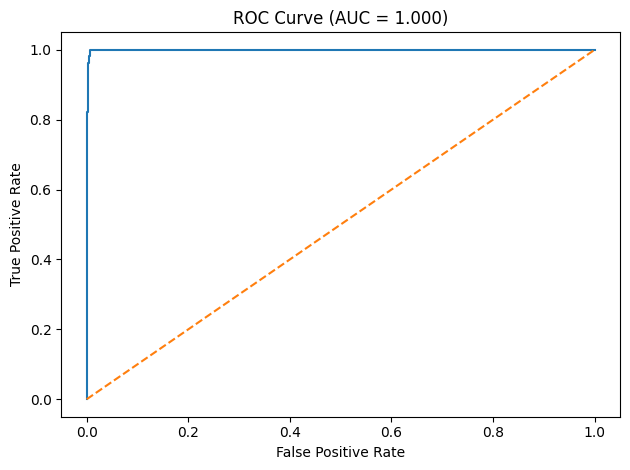

,coefficient
active_days,-4.940970
total_skips,-3.167661
total_minutes,-1.524841
total_likes,-0.642961
monthly_price_eur,0.358993
total_sessions,0.204823


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler

model_features = ["total_minutes","total_sessions","active_days","total_skips","total_likes","monthly_price_eur"]
X2 = df[model_features].fillna(0)
y = df["churned_14d"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.25, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train_s = scaler2.fit_transform(X_train)
X_test_s = scaler2.transform(X_test)

lr = LogisticRegression(max_iter=300)
lr.fit(X_train_s, y_train)

pred = lr.predict(X_test_s)
proba = lr.predict_proba(X_test_s)[:, 1]

print(classification_report(y_test, pred, digits=3))
print("ROC AUC:", round(roc_auc_score(y_test, proba), 3))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

coef = pd.Series(lr.coef_[0], index=model_features).sort_values(key=np.abs, ascending=False)
display(coef.to_frame("coefficient"))


## 6) Quick visuals

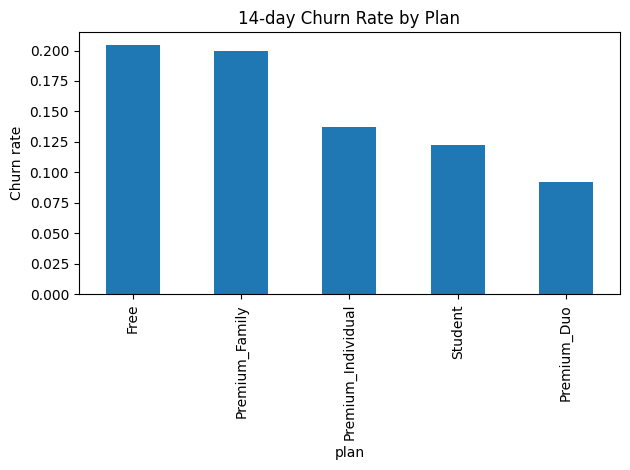

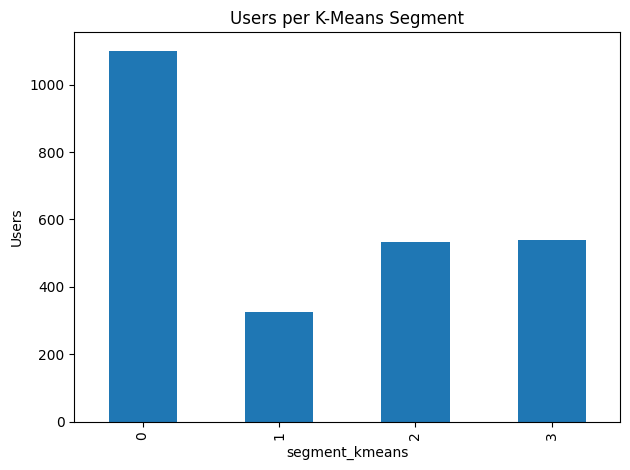

In [7]:
# Churn by plan
churn_by_plan = df.groupby("plan")["churned_14d"].mean().sort_values(ascending=False)
plt.figure()
churn_by_plan.plot(kind="bar")
plt.title("14-day Churn Rate by Plan")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()

# Segment sizes
seg_size = df["segment_kmeans"].value_counts().sort_index()
plt.figure()
seg_size.plot(kind="bar")
plt.title("Users per K-Means Segment")
plt.ylabel("Users")
plt.tight_layout()
plt.show()
